# BEE 4750 Homework 5: Mixed Integer and Stochastic Programming

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 12/04/24, 9:00pm

## Overview

### Instructions

-   In Problem 1, you will use mixed integer programming to solve a
    waste load allocation problem.
-   In Problem 2, you will formulate a stochastic optimization problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/hw5-lmk263-1`


In [6]:
using JuMP
using HiGHS
using DataFrames
using GraphRecipes
using Plots
using Measures
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (24 points)

Three cities are developing a coordinated municipal solid waste (MSW)
disposal plan. Three disposal alternatives are being considered: a
landfill (LF), a materials recycling facility (MRF), and a
waste-to-energy facility (WTE). The capacities of these facilities and
the fees for operation and disposal are provided below.

-   **LF**: Capacity 200 Mg, fixed cost \$2000/day, tipping cost
    \$50/Mg;
-   **MRF**: Capacity 350 Mg, fixed cost \$1500/day, tipping cost
    \$7/Mg, recycling cost \$40/Mg recycled;
-   **WTE**: Capacity 210 Mg, fixed cost \$2500/day, tipping cost
    \$60/Mg;

The MRF recycling rate is 40%, and the ash fraction of non-recycled
waste is 16% and of recycled waste is 14%. Transportation costs are
\$1.5/Mg-km, and the relative distances between the cities and
facilities are provided in the table below.

| **City/Facility** | **Landfill (km)** | **MRF (km)** | **WTE (km)** |
|:-----------------:|:-----------------:|:------------:|:------------:|
|         1         |         5         |      30      |      15      |
|         2         |        15         |      25      |      10      |
|         3         |        13         |      45      |      20      |
|        LF         |        \-         |      32      |      18      |
|        MRF        |        32         |      \-      |      15      |
|        WTE        |        18         |      15      |      \-      |

The fixed costs associated with the disposal options are incurred only
if the particular disposal option is implemented. The three cities
produce 100, 90, and 120 Mg/day of solid waste, respectively, with the
composition provided in the table below.

| **Component** | **% of total mass** | **Combustion ash** (%) | **MRF Recycling rate** (%) |
|:---------------------:|:--------------:|:---------------:|:---------------:|
| Food Wastes | 15 | 8 | 0 |
| Paper & Cardboard | 40 | 7 | 55 |
| Plastics | 5 | 5 | 15 |
| Textiles | 3 | 10 | 10 |
| Rubber, Leather | 2 | 15 | 0 |
| Wood | 5 | 2 | 30 |
| Yard Wastes | 18 | 2 | 40 |
| Glass | 4 | 100 | 60 |
| Ferrous | 2 | 100 | 75 |
| Aluminum | 2 | 100 | 80 |
| Other Metal | 1 | 100 | 50 |
| Miscellaneous | 3 | 70 | 0 |

The information in the above table will help you determine the overall
recycling and ash fractions. Note that the recycling residuals, which
may be sent to either landfill or the WTE, have different ash content
than the ash content of the original MSW. You will need to determine
these fractions to construct your mass balance constraints.

**Reminder**: Use `round(x; digits=n)` to report values to the
appropriate precision!

#### Problem 1.1

Based on the information above, calculate the overall recycling and ash
fractions for the waste produced by each city.

In [47]:
# City waste totals (Mg/day)
city_waste = [100, 90, 120]

# Component fractions of total waste
comp_frac = [0.15, 0.40, 0.05, 0.03, 0.02, 0.05, 0.18, 0.04, 0.02, 0.02, 0.01, 0.03]

# Component recycling rates
comp_recycle = [0, 0.55, 0.15, 0.10, 0, 0.30, 0.40, 0.60, 0.75, 0.80, 0.50, 0]

# Component ash fractions
comp_ash = [0.08, 0.07, 0.05, 0.10, 0.15, 0.02, 0.02, 1.0, 1.0, 1.0, 1.0, 0.70]

# Ash fractions for MRF
ash_recycled = 0.14
ash_residual = 0.16

# Initialize arrays
recycling_frac = Float64[]
ash_frac = Float64[]

# Loop over cities
for (i, city_mass) in enumerate(city_waste)
    recycled_mass = 0.0
    ash_mass = 0.0
    for j in 1:length(comp_frac)
        mass = city_mass * comp_frac[j]
        r = comp_recycle[j]
        recycled_mass += mass * r
        ash_mass += mass * (r*ash_recycled + (1-r)*ash_residual)
    end
    push!(recycling_frac, round(recycled_mass/city_mass, digits=2))
    push!(ash_frac, round(ash_mass/city_mass, digits=2))
end

println("Overall recycling fractions per city: ", recycling_frac)
println("Overall ash fractions per city: ", ash_frac)


Overall recycling fractions per city: [0.38, 0.38, 0.38]
Overall ash fractions per city: [0.15, 0.15, 0.15]


#### Problem 1.2

What are the decision variables for your optimization problem? Provide
notation and variable meaning.

#### Problem 1.3

Formulate the objective function. Make sure to include any needed
derivations or justifications for your equation(s).

#### Problem 1.4

Derive all relevant constraints. Make sure to include any needed
justifications or derivations.

#### Problem 1.5

Find the optimal solution (using `JuMP` to solve the problem). Report
the optimal objective value.

Running HiGHS 1.12.0 (git hash: 755a8e027): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 6 rows; 12 cols; 21 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 4e+02]
  Cost    [6e+01, 2e+03]
  Bound   [1e+00, 1e+00]
  RHS     [9e+01, 1e+02]
Presolving model
6 rows, 12 cols, 21 nonzeros  0s
6 rows, 12 cols, 21 nonzeros  0s
Presolve reductions: rows 6(-0); columns 12(-0); nonzeros 21(-0) - Not reduced

Solving MIP model with:
   6 rows
   12 cols (3 binary, 0 integer, 0 implied int., 9 continuous, 0 domain fixed)
   21 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |          

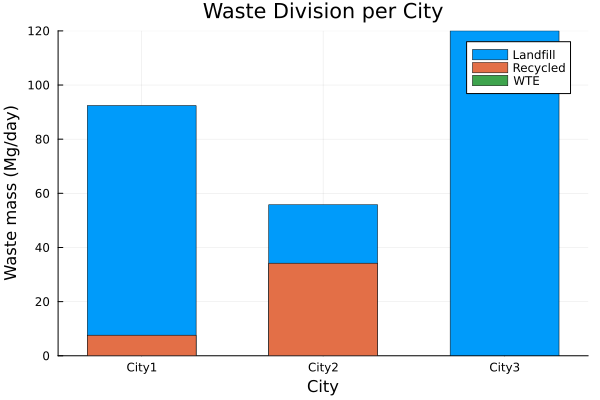

In [10]:

# ---------------------------
# Problem data
# ---------------------------
cities = [:City1, :City2, :City3]
W = Dict(:City1 => 100.0, :City2 => 90.0, :City3 => 120.0)

facilities = [:LF, :MRF, :WTE]

Cap = Dict(:LF => 200.0, :MRF => 350.0, :WTE => 210.0)
Cf = Dict(:LF => 2000.0, :MRF => 1500.0, :WTE => 2500.0)
Ct = Dict(:LF => 50.0, :MRF => 7.0, :WTE => 60.0)
Cr = 40.0
Ctr = 1.5

dist = Dict(
    (:City1, :LF)  => 5.0,  (:City1, :MRF) => 30.0, (:City1, :WTE) => 15.0,
    (:City2, :LF)  => 15.0, (:City2, :MRF) => 25.0, (:City2, :WTE) => 10.0,
    (:City3, :LF)  => 13.0, (:City3, :MRF) => 45.0, (:City3, :WTE) => 20.0
)

R = Dict(:City1 => 0.38, :City2 => 0.38, :City3 => 0.38)
A = Dict(:City1 => 0.15, :City2 => 0.15, :City3 => 0.15)

# ---------------------------
# Build optimization model
# ---------------------------
model = Model(HiGHS.Optimizer)

@variable(model, M[cities, facilities] >= 0)
@variable(model, y[facilities], Bin)

@expression(model, recycled[city in cities], R[city] * M[city, :MRF])
@expression(model, ash_mass,
    sum(A[city] * ( M[city, :WTE] + (1.0 - R[city]) * M[city, :MRF] ) for city in cities)
)

@objective(model, Min,
    sum(Cf[f]*y[f] for f in facilities) +
    sum(Ct[f]*M[city,f] for city in cities, f in facilities) +
    Ctr * sum(dist[(city,f)]*M[city,f] for city in cities, f in facilities) +
    Cr * sum(recycled[city] for city in cities) +
    Ct[:LF] * ash_mass
)

# ---------------------------
# Constraints
# ---------------------------
for city in cities
    @constraint(model, sum(M[city,f] for f in facilities) == W[city])
end

for f in facilities
    @constraint(model, sum(M[city,f] for city in cities) <= Cap[f] * y[f])
end

# ---------------------------
# Solve
# ---------------------------
optimize!(model)

status = termination_status(model)
obj = objective_value(model)

println("\n=== Optimization Results ===")
println("Status: ", status)
println("Optimal objective (total cost): \$", round(obj; digits=2))

# ---------------------------
# City → Facility flows
# ---------------------------
city_col = String[]
facility_col = String[]
mass_col = Float64[]

for city in cities, f in facilities
    push!(city_col, string(city))
    push!(facility_col, string(f))
    push!(mass_col, round(value(M[city,f]); digits=2))
end

flows_df = DataFrame(City = city_col, Facility = facility_col, Mass_Mg = mass_col)
println("\nCity → Facility flows (Mg/day):")
MarkdownTables.markdown_table(flows_df) |> println

# ---------------------------
# Facility usage
# ---------------------------
bin_df = DataFrame(
    Facility = [string(f) for f in facilities],
    Open = [Int(round(value(y[f]))) for f in facilities],
    Capacity = [Cap[f] for f in facilities],
    Used = [ round(sum(value(M[city,f]) for city in cities); digits=2) for f in facilities ]
)
println("\nFacility usage:")
MarkdownTables.markdown_table(bin_df) |> println

# ---------------------------
# Recycling & ash summary
# ---------------------------
recycled_per_city = [ round(value(recycled[city]); digits=2) for city in cities ]
total_recycled = round(sum(recycled_per_city); digits=2)
ash_total = round(value(ash_mass); digits=2)

println("\nRecycling per city (Mg/day):")
for (i, city) in enumerate(cities)
    println("  ", city, ": ", recycled_per_city[i], " Mg")
end
println("Total recycled: ", total_recycled, " Mg")
println("Total ash mass to be disposed (Mg): ", ash_total)

# ---------------------------
# Cost breakdown
# ---------------------------
fixed_costs = sum(Cf[f]*value(y[f]) for f in facilities)
tipping_costs = sum(Ct[f]*value(M[city,f]) for city in cities, f in facilities)
transport_costs = Ctr * sum(dist[(city,f)]*value(M[city,f]) for city in cities, f in facilities)
recycling_costs = Cr * total_recycled
ash_costs = Ct[:LF] * ash_total

breakdown = DataFrame(
    item = ["fixed_costs","tipping_costs","transport_costs","recycling_costs","ash_costs","objective_total"],
    value = [ round(fixed_costs; digits=2), round(tipping_costs; digits=2),
              round(transport_costs; digits=2), round(recycling_costs; digits=2),
              round(ash_costs; digits=2), round(obj; digits=2) ]
)
println("\nCost breakdown (\$):")
MarkdownTables.markdown_table(breakdown) |> println

# ---------------------------
# Plot total inflow per facility
# ---------------------------
facility_flow = [ sum(value(M[city,f]) for city in cities) for f in facilities ]
bar_labels = [string(f) for f in facilities]
bar(bar_labels, facility_flow, legend=false, xlabel="Facility", ylabel="Total mass (Mg/day)",
    title="Total inflow by facility (Mg/day)")

# ---------------------------
# Plot waste division per city
# ---------------------------
# Each city's contribution to LF, MRF (recycled vs residual), WTE
city_data = DataFrame(
    City = [string(city) for city in cities],
    Landfill = [round(value(M[city,:LF]) + (1-R[city])*value(M[city,:MRF]); digits=2) for city in cities],
    Recycled = [round(value(recycled[city]); digits=2) for city in cities],
    WTE = [round(value(M[city,:WTE]); digits=2) for city in cities]
)

bar(
    city_data.City,
    [city_data.Landfill city_data.Recycled city_data.WTE],
    label = ["Landfill" "Recycled" "WTE"],
    xlabel = "City",
    ylabel = "Waste mass (Mg/day)",
    title = "Waste Division per City",
    legend=:topright,
    lw=0.5,
    bar_width=0.6
)


#### Problem 1.6

Draw a diagram showing the flows of waste between the cities and the
facilities. Which facilities (if any) will not be used? Does this
solution make sense?

### Problem 2 (6 points)

Consider a two-period economic dispatch problem, based on the
multi-period example from Lecture 14 (on 10/29). The generator data,
including ramping constraints for each generator, is provided in
\`data/generators.csv.’ In period 1, the demand is
$d_1 = 1100 \text{MW}$. In period 2, the demand is projected to be
$d_2 = 1200 \text{MW}$, but there is a 25% probability that it is \$1500
. In the first period, the solar capacity factor is $0.9$ and the wind
capacity factor is $0.45$, but in the second period, there is some
uncertainty: the forecasted solar and wind capacity factors are $0.95$
and $0.4$, respectively, but there is a 30% probability that they are
$0.75$ and $0.5$. Your goal is to identify how to dispatch your
generators to minimize the cost of meeting demand.

#### Problem 2.1

Draw a scenario tree for this problem.

#### Problem 2.2

Formulate a stochastic linear program for this problem based on your
scenario tree from Problem 2.1 and the data in `data/generators.csv`.

## References

List any external references consulted, including classmates.